##Experimento 1

In [1]:
def busca_v1_(x, L):
  i = 0
  busca = None
  n = len(L)
  while i < n:
    if L[i] == x:
      busca = i
      i = n + 1
    else:
      i = i + 1
  return busca


In [ ]:
def busca_v2_(x, L):
  n = len(L)
  L.append(x)
  i = 0
  while L[i] != x:
    i = i + 1
  if i != n+1:
    return i
  else:
    return None


In [2]:
def busca_v1(x, L):
  contador = 0
  i = 0
  contador+=1
  busca = None
  contador+=1
  n = len(L)
  contador+=1
  while i < n:
    contador+=1
    if L[i] == x:
      contador+=1
      busca = i
      contador+=1
      i = n + 1
      contador+=1
    else:
      contador+=1
      i = i + 1
      contador+=1
  return busca, contador


In [6]:
def busca_v2(x, L):
  contador = 0
  n = len(L)
  contador+=1
  L.append(x)
  contador+=1
  i = 0
  contador+=1
  while L[i] != x:
    contador+=1
    i = i + 1
    contador+=1
  if i != n:
    contador+=1
    return i,contador
  else:
    contador+=1
    return None, contador


In [4]:
import random as r
def gerar_lista(N):
  return [r.randint(0, N) for i in range(N)]

def sorteia_numero(N):
  return r.randint(0, N)


In [10]:
L = gerar_lista(1000)
x = sorteia_numero(1000)
print(busca_v1(x, L))
print(busca_v2(x, L))

(979, 2944)
(979, 1962)


In [ ]:
L1 = []
L2 = []
for N in range(1000, 100000, 500):
  L = gerar_lista(N)
  x = sorteia_numero(N)
  _, v1 = busca_v1(x, L)
  _, v2 = busca_v2(x, L)
  L1.append(v1)
  L2.append(v2)


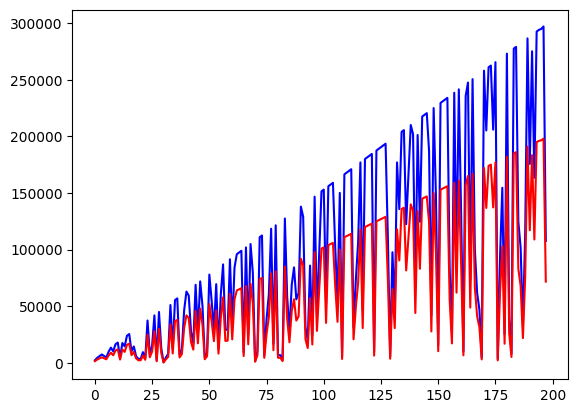

In [ ]:
import matplotlib.pyplot as plt
plt.plot(L1, color = 'b')
plt.plot(L2, color = 'r')
plt.show()

##Pilha em alocação sequêncial

In [15]:
PILHA = [None]*5
topo = -1

In [16]:
PILHA

[None, None, None, None, None]

In [17]:
def inserir_pilha(x):
  global topo
  n = len(PILHA)-1
  if topo != n:
    topo += 1
    PILHA[topo] = x
  else:
    raise Exception("overflow")

In [18]:
def remover_pilha():
  global topo
  if topo != -1:
    valor = PILHA[topo]
    topo -= 1
    return valor
  else:
    raise Exception("underflow")

In [33]:
try:
  inserir_pilha(1)
  print(PILHA, topo)
except Exception as e:
  print(e)


overflow


In [34]:
try:
  valor = remover_pilha()
  print(PILHA, valor, topo)
except Exception as e:
  print(e)


[5, 15, 1, 1, 1] 1 3


##Fila em alocação sequêncial

In [57]:
FILA = [None]*5
f, r = -1, -1

In [58]:
FILA

[None, None, None, None, None]

In [59]:
def inserir_fila(x):
  global f, r
  M = len(FILA)
  prov = (r+1) % M
  if prov != f:
    r = prov
    FILA[r] = x
    if f == -1:
      f = 0
  else:
    raise Exception("overflow")

In [60]:
def remover_fila():
  global f, r
  M = len(FILA)
  if f != -1:
    valor = FILA[f]
    if f == r:
      f, r = -1, -1
    else:
      f = (f % M) + 1
  else:
    raise Exception("underflow")



In [66]:
try:
  inserir_fila(22)
  print(FILA, f, r)
except Exception as e:
  print(e)


overflow


In [71]:
try:
  remover_fila()
  print(FILA, f, r)
except Exception as e:
  print(e)


[22, 22, 22, 22, 22] -1 -1


##Lista simplesmente encadeada

In [72]:
class No:
  def __init__(self, chave, valor, prox):
    self.chave = chave
    self.valor = valor
    self.prox = prox


In [73]:
cabeca = No(None, None, None)

In [74]:
def buscar_lse(x):
  ant = cabeca
  pont = None
  ptr = cabeca.prox
  while ptr != None:
    if ptr.chave < x:
      ant = ptr
      ptr = ptr.prox
    elif ptr.chave == x:
      pont = ptr
      ptr = None
    else:
      ptr = None
  return ant, pont

In [75]:
def imprimir_lse():
  ptr = cabeca.prox
  while ptr != None:
    print(ptr.chave, ptr.valor)
    ptr = ptr.prox


In [76]:
def inserir_lse(chave, valor):
  ant, pont = buscar_lse(chave)
  if pont == None:
    novo_no = No(chave, valor, ant.prox)
    ant.prox = novo_no
  else:
    print("elemento já está na tabela")


In [77]:
def remover_lse(chave):
  ant, pont = buscar_lse(chave)
  if pont != None:
    ant.prox = pont.prox
    valor = pont.valor
    del pont
  else:
    print("chave não existe na lista")


In [87]:
inserir_lse(7, 44)

In [92]:
remover_lse(1)

In [93]:
imprimir_lse()

2 10
3 3
7 44


##Pilha LSE

In [94]:
class No:
  def __init__(self, chave, valor, prox):
    self.chave = chave
    self.valor = valor
    self.prox = prox


In [95]:
topo = None

In [96]:
def inserir_pilha_lse(chave, valor):
  global topo
  topo = No(chave, valor, topo)

In [97]:
def remover_pilha_lse():
  global topo
  if topo != None:
    no = topo
    topo = topo.prox
    chave, valor = no.chave, no.valor
    del no
    return chave, valor
  else:
    print("pilha vazia")

In [98]:
def imprimir_pilha_lse():
  ptr = topo
  while ptr != None:
    print(ptr.chave, ptr.valor)
    ptr = ptr.prox

In [111]:
inserir_pilha_lse(4,2)

In [118]:
remover_pilha_lse()

pilha vazia


In [119]:
imprimir_pilha_lse()